In [127]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import ast
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
import textwrap
import ast
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

In [111]:
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.title_fontsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.frameon": False,
    "figure.figsize": (9, 3)  # standard size for subplots
})
COLORS = ['#5F6F52', '#A9B388', '#B99470']
COLORS2 = ['#395144', '#4E6C50', '#AA8B56']

In [112]:
targets = ['live weight', 'carcass weight', 'price', 'Total number of defects']
# drop_features = ['kill date', 'kill year', 'kill month', 'Processing location', 'Presentation Grade', 'Grade', 
#                  'Teeth', 'Yield', 'Animal Type_num', 'Grade_num', 'Presentation Grade_num', 'Waste',
#                  "price/kg", 'Animal Type', 'max_lag']
drop_features = ['kill date', 'kill year', 'kill month', 'Processing location', 'Presentation Grade', 'Grade', 
                 'Teeth', 'Yield', 'Grade_num', 'Presentation Grade_num', 'Waste', 'Age',
                 "price/kg", 'Animal Type']

In [113]:
# load preprocessed data files
beef = pd.read_csv('data/beef_preprocessed.csv')
df_win = pd.read_csv('data/beef_weather_windows.csv')
data =  beef.join(df_win)
data = data[data['Animal Type'] != 'cow'].copy()

# Spearman Correlation

In [114]:
# Identify weather features (our engineered window features)
weather_features = [c for c in data.columns if "__win" in c]

# Static features: everything that's not a target, not a weather feature, not in drop_features
static_features = [
    c for c in data.columns
    if c not in targets
    and c not in drop_features
    and "__win" not in c
]

print("Number of static features:", len(static_features))
print("Number of weather features:", len(weather_features))

Number of static features: 4
Number of weather features: 310


In [115]:
animal_types = ["steer", "heifer"]
corr_results = {}

for atype in animal_types:
    sub = data[data["Animal Type"].astype(str).str.lower() == atype].copy()
    
    # keep only price + weather, drop rows with missing values
    cols = ["price"] + weather_features
    sub = sub[cols].dropna()
    if sub.empty:
        print(f"No data for {atype}, skipping.")
        continue
    
    # Spearman correlation of each weather feature with price
    corrs = sub[weather_features].corrwith(sub["price"], method="spearman")
    corrs = corrs.dropna()
    
    corr_df = (
        corrs.to_frame("spearman_corr")
             .assign(abs_corr=lambda df: df["spearman_corr"].abs())
             .sort_values("abs_corr", ascending=False)
    )
    corr_results[atype] = corr_df


c:\Users\kdo88\Repos\Weather-CattleHealth\.venv\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


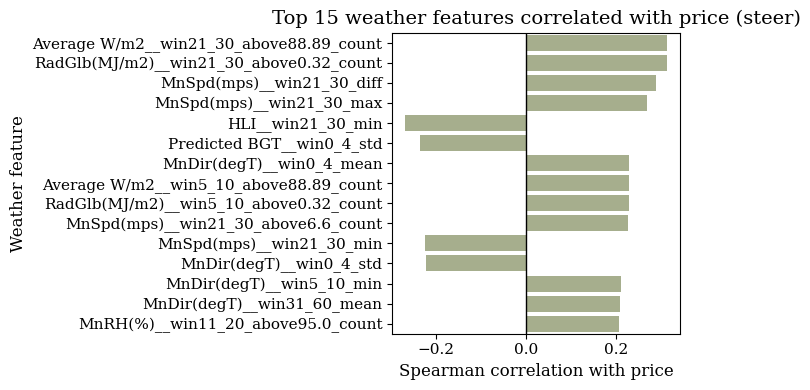

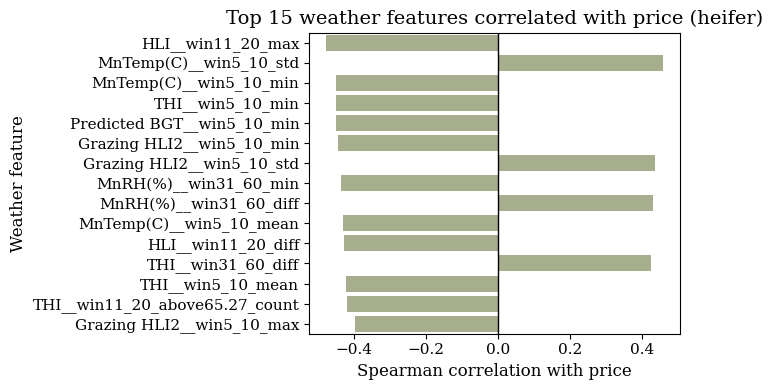

In [116]:
topN = 15

for atype, corr_df in corr_results.items():
    top_corr = corr_df.head(topN).reset_index().rename(columns={"index": "feature"})
    
    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=top_corr,
        x="spearman_corr",
        y="feature",
        color=COLORS[1]
    )
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Top {topN} weather features correlated with price ({atype})")
    plt.xlabel("Spearman correlation with price")
    plt.ylabel("Weather feature")
    plt.tight_layout()
    plt.savefig(f"figs/meat_spearman_{atype}.svg", bbox_inches="tight")
    plt.savefig(f"figs/meat_spearman_{atype}.png", dpi=300, bbox_inches="tight")
    plt.show()

# Train ElasticNet with top hyperparameters

In [117]:
# Obtain best hyperparams from CV results (beef_predictive_modeling.ipynb))
enet_results = pd.read_csv("results/cv_results_on_animals_windows.csv")
enet_params = enet_results[enet_results["model_name"].eq("ElasticNet")][
    ["animal_type", "target", "best_params"]
].drop_duplicates()

enet_params["best_params"] = enet_params["best_params"].apply(ast.literal_eval)
enet_params = enet_params.set_index(["target", "animal_type"])["best_params"].to_dict()

In [118]:
models_interpret = {}

for target in targets:
    for atype in ["steer", "heifer"]:
        sub = data[data["Animal Type"].str.lower() == atype].copy()
        sub = sub.dropna(subset=[target])

        X = sub[weather_features].copy()
        y = sub[target].copy()

        X = X.loc[:, X.notna().any(axis=0)]

        params = enet_params[(target, atype)]

        model = Pipeline([
            ("imputer", SimpleImputer(strategy=params["imputer_strategy"])),
            ("scaler", StandardScaler()),
            ("enet", ElasticNet(alpha=params["alpha"], l1_ratio=params["l1_ratio"],
                                 max_iter=50000, random_state=2210))
        ])

        model.fit(X, y)
        models_interpret[(target, atype)] = (model, X.columns)

c:\Users\kdo88\Repos\Weather-CattleHealth\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.049e+04, tolerance: 3.223e+01
  model = cd_fast.enet_coordinate_descent(


# Grouped Importance

In [119]:
def parse_weather_feature(feature):
    weather_var = feature.split("__")[0]
    rest = feature.split("__")[1]

    window = "_".join(rest.split("_")[:2]).replace("win", "")
    aggregation = "_".join(rest.split("_")[2:])

    feature_type = "extreme events" if "_count" in feature else "window aggregation"

    return weather_var, window, aggregation, feature_type

In [120]:
coef_rows = []

for atype, (model, cols) in models_interpret.items():
    coefs = pd.Series(model.named_steps["enet"].coef_, index=cols)
    coefs = coefs[coefs != 0]

    for feature, coef in coefs.items():
        weather_var, window, aggregation, feature_type = parse_weather_feature(feature)

        coef_rows.append({
            "animal_type": atype,
            "feature": feature,
            "weather_var": weather_var,
            "window": window,
            "aggregation": aggregation,
            "feature_type": feature_type,
            "coef": coef,
            "abs_coef": abs(coef),
        })

coef_df = pd.DataFrame(coef_rows)
coef_df["target"] = coef_df["animal_type"].apply(lambda x: x[0] if isinstance(x, tuple) else None)
coef_df["atype"] = coef_df["animal_type"].apply(lambda x: x[1] if isinstance(x, tuple) else x)
coef_df.head()

,animal_type,feature,weather_var,window,aggregation,feature_type,coef,abs_coef,target,atype
0,"(live weight, steer)",MnSpd(mps)__win0_4_above6.6_count,MnSpd(mps),0_4,above6.6_count,extreme events,-3.463873,3.463873,live weight,steer
1,"(live weight, steer)",Rain(mm)__win0_4_mean,Rain(mm),0_4,mean,window aggregation,9.653672,9.653672,live weight,steer
2,"(live weight, steer)",Predicted BGT__win0_4_diff,Predicted BGT,0_4,diff,window aggregation,-5.599452,5.599452,live weight,steer
3,"(live weight, steer)",Predicted BGT__win0_4_std,Predicted BGT,0_4,std,window aggregation,-1.594158,1.594158,live weight,steer
4,"(live weight, steer)",HLI__win0_4_diff,HLI,0_4,diff,window aggregation,2.317080,2.317080,live weight,steer


In [121]:
target = "price"
sub = coef_df[coef_df["target"].eq(target) & coef_df["atype"].isin(["steer", "heifer"])].copy()

## Importance per weather variable

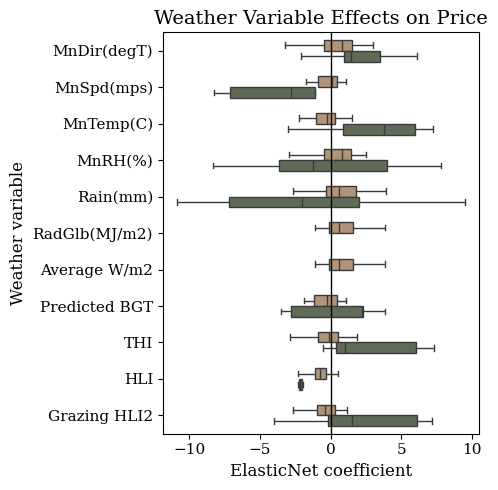

In [122]:
weather_order = (
    sub
    .groupby("weather_var")["abs_coef"]
    .sum()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(5, 5))

sns.boxplot(data=sub, x="coef", y="weather_var", hue="atype",
            palette=[COLORS[2], COLORS[0]], showfliers=False,
            width=0.6, linewidth=1, legend=False)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("ElasticNet coefficient")
plt.ylabel("Weather variable")
plt.title(f"Weather Variable Effects on {target.capitalize()}")
plt.tight_layout()

plt.savefig(f"figs/meat_grouped_weather_effects_{target}.svg", bbox_inches="tight")
plt.savefig(f"figs/meat_grouped_weather_effects_{target}.png", dpi=300, bbox_inches="tight")
plt.show()

## Importance per window

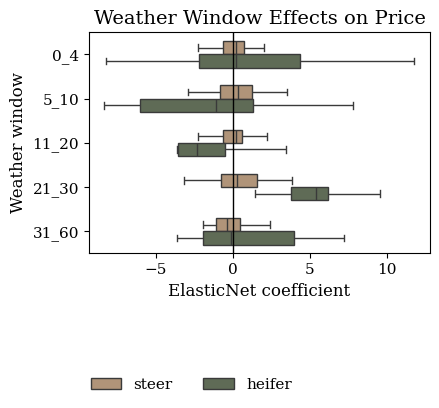

In [123]:
window_order = ["0_4", "5_10", "11_20", "21_30", "31_60"]
sub["window"] = pd.Categorical(sub["window"], categories=window_order, ordered=True)
sub = sub.sort_values("window")

plt.figure(figsize=(4.5, 5))

ax = sns.boxplot(data=sub, x="coef", y="window", hue="atype",
            palette=[COLORS[2], COLORS[0]], showfliers=False,
            width=0.6, linewidth=1)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("ElasticNet coefficient")
plt.ylabel("Weather window")
plt.title(f"Weather Window Effects on {target.capitalize()}")
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.3, -0.5),
          ncol=2, frameon=False)
plt.tight_layout()

plt.savefig(f"figs/meat_grouped_window_effects_{target}.svg", bbox_inches="tight")
plt.savefig(f"figs/meat_grouped_window_effects_{target}.png", dpi=300, bbox_inches="tight")
plt.show()

## Importance of exposure features vs. other per-window-summaries

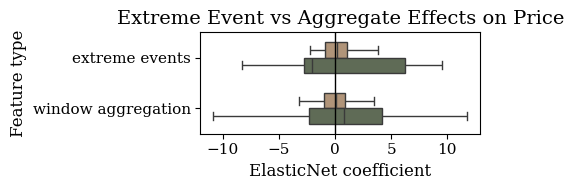

In [124]:
feature_type_order = ["extreme events", "window aggregation"]
sub["feature_type"] = pd.Categorical(sub["feature_type"], categories=feature_type_order, ordered=True)
sub = sub.sort_values("feature_type")

plt.figure(figsize=(5, 2))

sns.boxplot(data=sub, x="coef", y="feature_type", hue="atype",
            palette=[COLORS[2], COLORS[0]], showfliers=False,
            width=0.6, linewidth=1, legend=False)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("ElasticNet coefficient")
plt.ylabel("Feature type")
plt.title(f"Extreme Event vs Aggregate Effects on {target.capitalize()}")
plt.tight_layout()

plt.savefig(f"figs/meat_grouped_feature_type_effects_{target}.svg", bbox_inches="tight")
plt.savefig(f"figs/meat_grouped_feature_type_effects_{target}.png", dpi=300, bbox_inches="tight")
plt.show()

# Individual Importance

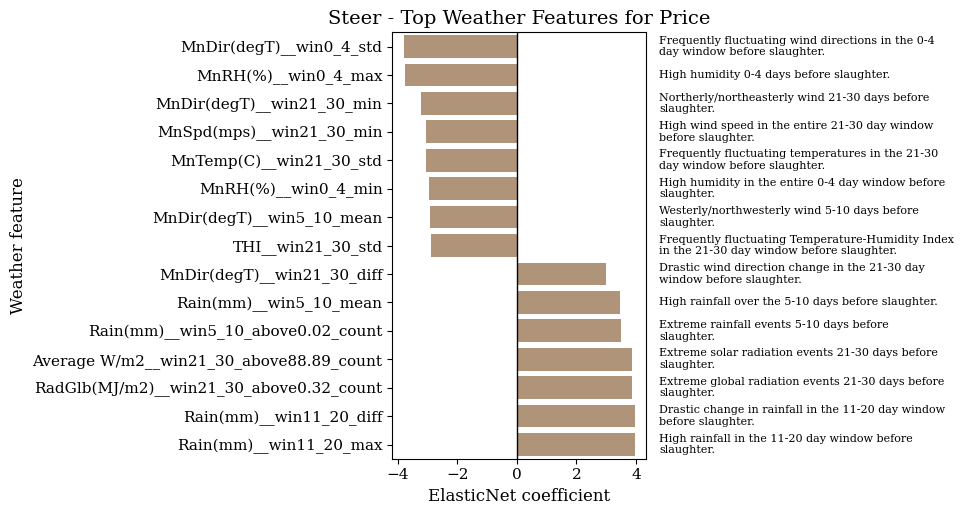

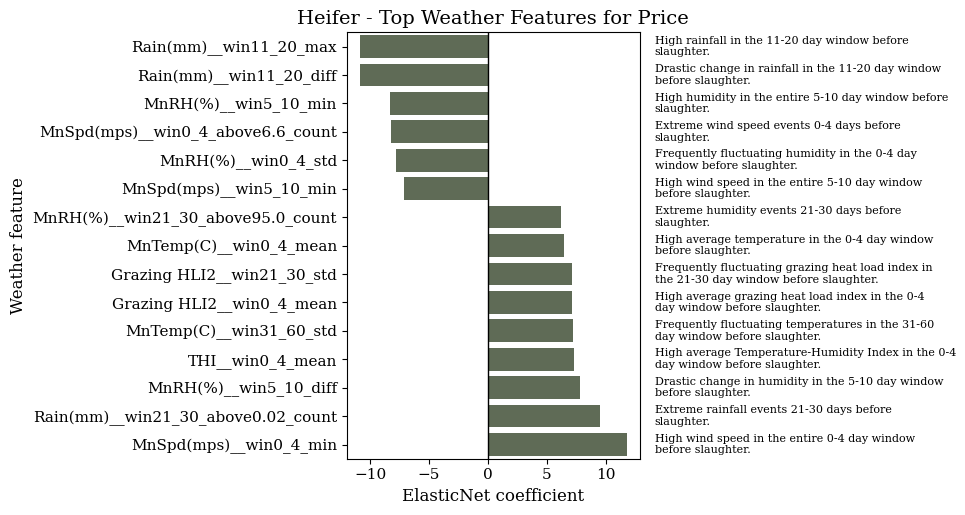

In [126]:
topN = 15

feature_explanations = {
    'MnDir(degT)__win0_4_std': 'Frequently fluctuating wind directions in the 0-4 day window before slaughter.',
    'MnRH(%)__win0_4_max': 'High humidity 0-4 days before slaughter.',
    'MnDir(degT)__win21_30_min': 'Northerly/northeasterly wind 21-30 days before slaughter.',
    'MnSpd(mps)__win21_30_min': 'High wind speed in the entire 21-30 day window before slaughter.',
    'MnTemp(C)__win21_30_std': 'Frequently fluctuating temperatures in the 21-30 day window before slaughter.',
    'MnRH(%)__win0_4_min': 'High humidity in the entire 0-4 day window before slaughter.',
    'MnDir(degT)__win5_10_mean': 'Westerly/northwesterly wind 5-10 days before slaughter.',
    'THI__win21_30_std': 'Frequently fluctuating Temperature-Humidity Index in the 21-30 day window before slaughter.',
    'MnDir(degT)__win21_30_diff': 'Drastic wind direction change in the 21-30 day window before slaughter.',
    'Rain(mm)__win5_10_mean': 'High rainfall over the 5-10 days before slaughter.',
    'Rain(mm)__win5_10_above0.02_count': 'Extreme rainfall events 5-10 days before slaughter.',
    'Average W/m2__win21_30_above88.89_count': 'Extreme solar radiation events 21-30 days before slaughter.',
    'RadGlb(MJ/m2)__win21_30_above0.32_count': 'Extreme global radiation events 21-30 days before slaughter.',
    'Rain(mm)__win11_20_diff': 'Drastic change in rainfall in the 11-20 day window before slaughter.',
    'Rain(mm)__win11_20_max': 'High rainfall in the 11-20 day window before slaughter.',
    'MnRH(%)__win5_10_min': 'High humidity in the entire 5-10 day window before slaughter.',
    'MnSpd(mps)__win0_4_above6.6_count': 'Extreme wind speed events 0-4 days before slaughter.',
    'MnRH(%)__win0_4_std': 'Frequently fluctuating humidity in the 0-4 day window before slaughter.',
    'MnSpd(mps)__win5_10_min': 'High wind speed in the entire 5-10 day window before slaughter.',
    'MnRH(%)__win21_30_above95.0_count': 'Extreme humidity events 21-30 days before slaughter.',
    'MnTemp(C)__win0_4_mean': 'High average temperature in the 0-4 day window before slaughter.',
    'Grazing HLI2__win21_30_std': 'Frequently fluctuating grazing heat load index in the 21-30 day window before slaughter.',
    'Grazing HLI2__win0_4_mean': 'High average grazing heat load index in the 0-4 day window before slaughter.',
    'MnTemp(C)__win31_60_std': 'Frequently fluctuating temperatures in the 31-60 day window before slaughter.',
    'THI__win0_4_mean': 'High average Temperature-Humidity Index in the 0-4 day window before slaughter.',
    'MnRH(%)__win5_10_diff': 'Drastic change in humidity in the 5-10 day window before slaughter.',
    'Rain(mm)__win21_30_above0.02_count': 'Extreme rainfall events 21-30 days before slaughter.',
    'MnSpd(mps)__win0_4_min': 'High wind speed in the entire 0-4 day window before slaughter.'
}

for atype, color in [("steer", COLORS[2]), ("heifer", COLORS[0])]:
    sub = coef_df[coef_df["target"].eq(target) & coef_df["atype"].eq(atype)].copy()
    sub = sub.reindex(sub["coef"].abs().sort_values(ascending=False).index).head(topN)
    sub = sub.sort_values("coef")

    fig, ax = plt.subplots(figsize=(10, max(4, topN * 0.35)))

    sns.barplot(data=sub, x="coef", y="feature", color=color, ax=ax)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"{atype.capitalize()} - Top Weather Features for {target.capitalize()}")
    ax.set_xlabel("ElasticNet coefficient")
    ax.set_ylabel("Weather feature")

    x_min, x_max = ax.get_xlim()
    x_text = x_max + (x_max - x_min) * 0.05

    for i, (_, row) in enumerate(sub.iterrows()):
        explanation = feature_explanations.get(row["feature"], "")
        explanation = "\n".join(textwrap.wrap(explanation, width=50))
        ax.text(x_text, i, explanation, va="center", ha="left", fontsize=8)

    # ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.55)

    plt.tight_layout()
    plt.savefig(f"figs/meat_individual_weather_effects_{atype}_{target}.svg", bbox_inches="tight")
    plt.savefig(f"figs/meat_individual_weather_effects_{atype}_{target}.png", dpi=300, bbox_inches="tight")
    plt.show()

# Defects

In [128]:
clf_results = pd.read_csv("results/cv_results_defect_classification.csv")
logit_params = clf_results[clf_results["model_name"].eq("Logistic Regression")][
    ["animal_type", "best_params"]
].drop_duplicates()

logit_params["best_params"] = logit_params["best_params"].apply(ast.literal_eval)
logit_params = logit_params.set_index("animal_type")["best_params"].to_dict()

In [131]:
defect_models_interpret = {}

y_defect = (data["Total number of defects"] > 0).astype(int)

for atype in ["steer", "heifer"]:
    sub = data[data["Animal Type"].str.lower().eq(atype)].copy()
    idx = sub.index[data.loc[sub.index, "Total number of defects"].notna()]

    X = data.loc[idx, weather_features].copy()
    y = y_defect.loc[idx].copy()

    X = X.loc[:, X.notna().any(axis=0)]

    params = logit_params[atype]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy=params.get("imputer_strategy", "median"))),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=params.get("C", 1),
                                     l1_ratio=params.get("l1_ratio", 0.5),
                                     penalty="elasticnet",
                                     solver="saga",
                                     max_iter=5000,
                                     class_weight="balanced",
                                     random_state=2210))
    ])

    model.fit(X, y)
    defect_models_interpret[atype] = (model, X.columns)

In [136]:
defect_coef_rows = []

for atype, (model, cols) in defect_models_interpret.items():
    coefs = pd.Series(model.named_steps["model"].coef_[0], index=cols)
    coefs = coefs[coefs != 0]

    for feature, coef in coefs.items():
        weather_var, window, aggregation, feature_type = parse_weather_feature(feature)

        defect_coef_rows.append({
            "atype": atype,
            "feature": feature,
            "weather_var": weather_var,
            "window": window,
            "aggregation": aggregation,
            "feature_type": feature_type,
            "coef": coef,
            "abs_coef": abs(coef),
        })

defect_coef_df = pd.DataFrame(defect_coef_rows)

In [138]:
target = "defects"

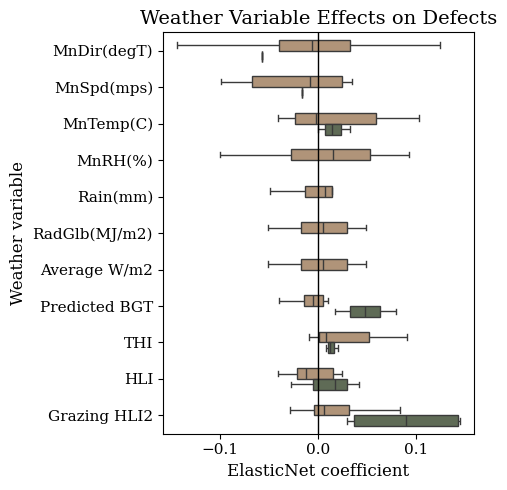

In [140]:
weather_order = (
    defect_coef_df
    .groupby("weather_var")["abs_coef"]
    .sum()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(5, 5))

sns.boxplot(data=defect_coef_df, x="coef", y="weather_var", hue="atype",
            palette=[COLORS[2], COLORS[0]], showfliers=False,
            width=0.6, linewidth=1, legend=False)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("ElasticNet coefficient")
plt.ylabel("Weather variable")
plt.title(f"Weather Variable Effects on {target.capitalize()}")
plt.tight_layout()

plt.savefig(f"figs/meat_grouped_weather_effects_{target}.svg", bbox_inches="tight")
plt.savefig(f"figs/meat_grouped_weather_effects_{target}.png", dpi=300, bbox_inches="tight")
plt.show()

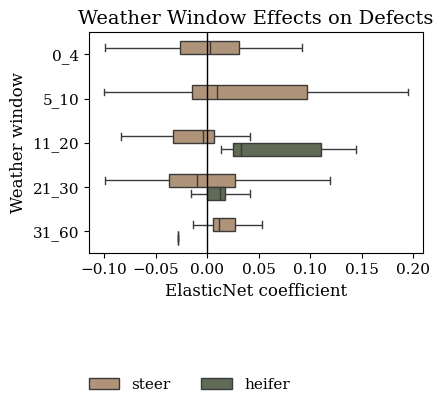

In [142]:
window_order = ["0_4", "5_10", "11_20", "21_30", "31_60"]
defect_coef_df["window"] = pd.Categorical(defect_coef_df["window"], categories=window_order, ordered=True)
defect_coef_df = defect_coef_df.sort_values("window")

plt.figure(figsize=(4.5, 5))

ax = sns.boxplot(data=defect_coef_df, x="coef", y="window", hue="atype",
            palette=[COLORS[2], COLORS[0]], showfliers=False,
            width=0.6, linewidth=1)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("ElasticNet coefficient")
plt.ylabel("Weather window")
plt.title(f"Weather Window Effects on {target.capitalize()}")
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.3, -0.5),
          ncol=2, frameon=False)
plt.tight_layout()

plt.savefig(f"figs/meat_grouped_window_effects_{target}.svg", bbox_inches="tight")
plt.savefig(f"figs/meat_grouped_window_effects_{target}.png", dpi=300, bbox_inches="tight")
plt.show()

In [143]:
for atype, color in [("steer", COLORS[2]), ("heifer", COLORS[0])]:
    sub = defect_coef_df[defect_coef_df["atype"].eq(atype)].copy()
    sub = sub.reindex(sub["coef"].abs().sort_values(ascending=False).index).head(topN)
    sub = sub.sort_values("coef")
    print(atype)
    print(sub["feature"].tolist())

steer
['MnSpd(mps)__win0_4_above6.6_count', 'MnDir(degT)__win11_20_std', 'MnDir(degT)__win11_20_min', 'MnTemp(C)__win5_10_diff', 'RadGlb(MJ/m2)__win5_10_diff', 'RadGlb(MJ/m2)__win5_10_max', 'Average W/m2__win5_10_max', 'Average W/m2__win5_10_diff', 'Rain(mm)__win21_30_mean', 'Predicted BGT__win5_10_diff', 'MnDir(degT)__win0_4_max', 'Rain(mm)__win31_60_mean', 'Rain(mm)__win31_60_std', 'MnDir(degT)__win5_10_std', 'MnRH(%)__win21_30_mean']
heifer
['MnDir(degT)__win21_30_mean', 'HLI__win31_60_above11.46_count', 'MnSpd(mps)__win21_30_above6.6_count', 'THI__win21_30_min', 'MnTemp(C)__win11_20_max', 'Predicted BGT__win21_30_min', 'HLI__win21_30_diff', 'THI__win11_20_max', 'Grazing HLI2__win11_20_max', 'MnTemp(C)__win11_20_diff', 'Grazing HLI2__win21_30_max', 'HLI__win21_30_max', 'Predicted BGT__win11_20_diff', 'Grazing HLI2__win11_20_std', 'Grazing HLI2__win11_20_diff']


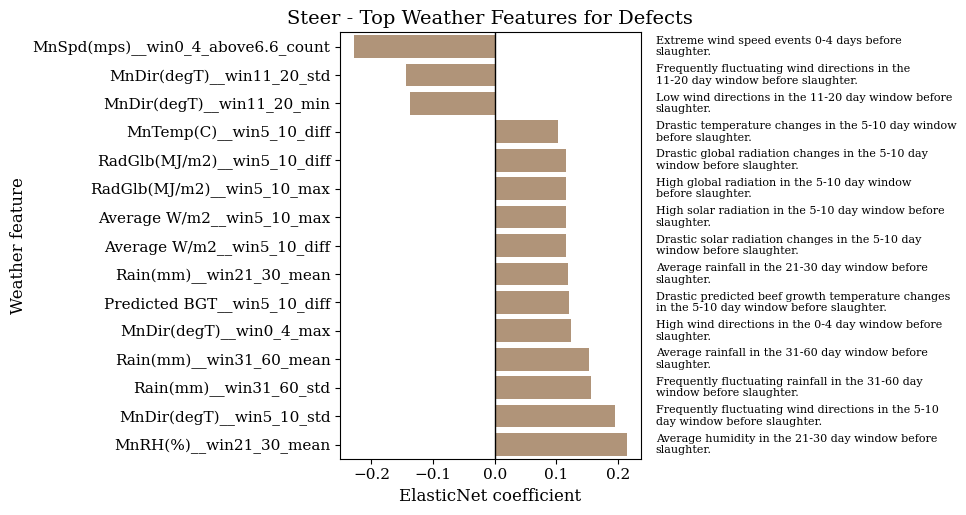

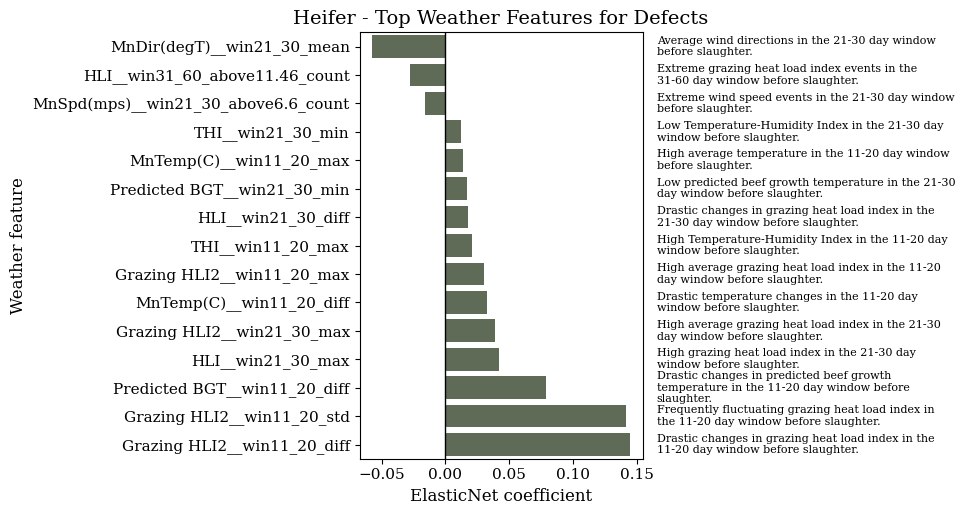

In [147]:
topN = 15

feature_explanations = {
    'MnSpd(mps)__win0_4_min': 'High wind speed in the entire 0-4 day window before slaughter.',
    'MnSpd(mps)__win0_4_above6.6_count': 'Extreme wind speed events 0-4 days before slaughter.',
    'MnDir(degT)__win11_20_std': 'Frequently fluctuating wind directions in the 11-20 day window before slaughter.',
    'MnDir(degT)__win11_20_min': 'Low wind directions in the 11-20 day window before slaughter.',
    'MnTemp(C)__win5_10_diff': 'Drastic temperature changes in the 5-10 day window before slaughter.',
    'RadGlb(MJ/m2)__win5_10_diff': 'Drastic global radiation changes in the 5-10 day window before slaughter.',
    'RadGlb(MJ/m2)__win5_10_max': 'High global radiation in the 5-10 day window before slaughter.',
    'Average W/m2__win5_10_max': 'High solar radiation in the 5-10 day window before slaughter.',
    'Average W/m2__win5_10_diff': 'Drastic solar radiation changes in the 5-10 day window before slaughter.',
    'Rain(mm)__win21_30_mean': 'Average rainfall in the 21-30 day window before slaughter.',
    'Predicted BGT__win5_10_diff': 'Drastic predicted beef growth temperature changes in the 5-10 day window before slaughter.',
    'MnDir(degT)__win0_4_max': 'High wind directions in the 0-4 day window before slaughter.',
    'Rain(mm)__win31_60_mean': 'Average rainfall in the 31-60 day window before slaughter.',
    'Rain(mm)__win31_60_std': 'Frequently fluctuating rainfall in the 31-60 day window before slaughter.',
    'MnDir(degT)__win5_10_std': 'Frequently fluctuating wind directions in the 5-10 day window before slaughter.',
    'MnRH(%)__win21_30_mean': 'Average humidity in the 21-30 day window before slaughter.',
    'MnDir(degT)__win21_30_mean': 'Average wind directions in the 21-30 day window before slaughter.',
    'HLI__win31_60_above11.46_count': 'Extreme grazing heat load index events in the 31-60 day window before slaughter.',
    'MnSpd(mps)__win21_30_above6.6_count': 'Extreme wind speed events in the 21-30 day window before slaughter.',
    'THI__win21_30_min': 'Low Temperature-Humidity Index in the 21-30 day window before slaughter.',
    'MnTemp(C)__win11_20_max': 'High average temperature in the 11-20 day window before slaughter.',
    'Predicted BGT__win21_30_min': 'Low predicted beef growth temperature in the 21-30 day window before slaughter.',
    'HLI__win21_30_diff': 'Drastic changes in grazing heat load index in the 21-30 day window before slaughter.',
    'THI__win11_20_max': 'High Temperature-Humidity Index in the 11-20 day window before slaughter.',
    'Grazing HLI2__win11_20_max': 'High average grazing heat load index in the 11-20 day window before slaughter.',
    'MnTemp(C)__win11_20_diff': 'Drastic temperature changes in the 11-20 day window before slaughter.',
    'Grazing HLI2__win21_30_max': 'High average grazing heat load index in the 21-30 day window before slaughter.',
    'HLI__win21_30_max': 'High grazing heat load index in the 21-30 day window before slaughter.',
    'Predicted BGT__win11_20_diff': 'Drastic changes in predicted beef growth temperature in the 11-20 day window before slaughter.',
    'Grazing HLI2__win11_20_std': 'Frequently fluctuating grazing heat load index in the 11-20 day window before slaughter.',
    'Grazing HLI2__win11_20_diff': 'Drastic changes in grazing heat load index in the 11-20 day window before slaughter.'
}

for atype, color in [("steer", COLORS[2]), ("heifer", COLORS[0])]:
    sub = defect_coef_df[defect_coef_df["atype"].eq(atype)].copy()
    sub = sub.reindex(sub["coef"].abs().sort_values(ascending=False).index).head(topN)
    sub = sub.sort_values("coef")

    fig, ax = plt.subplots(figsize=(10, max(4, topN * 0.35)))

    sns.barplot(data=sub, x="coef", y="feature", color=color, ax=ax)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"{atype.capitalize()} - Top Weather Features for {target.capitalize()}")
    ax.set_xlabel("ElasticNet coefficient")
    ax.set_ylabel("Weather feature")

    x_min, x_max = ax.get_xlim()
    x_text = x_max + (x_max - x_min) * 0.05

    for i, (_, row) in enumerate(sub.iterrows()):
        explanation = feature_explanations.get(row["feature"], "")
        explanation = "\n".join(textwrap.wrap(explanation, width=50))
        ax.text(x_text, i, explanation, va="center", ha="left", fontsize=8)

    # ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.55)

    plt.tight_layout()
    plt.savefig(f"figs/meat_individual_weather_effects_{atype}_{target}.svg", bbox_inches="tight")
    plt.savefig(f"figs/meat_individual_weather_effects_{atype}_{target}.png", dpi=300, bbox_inches="tight")
    plt.show()